<a href="https://colab.research.google.com/github/LielUziahu/Stylophora-pistillata-FPs/blob/main/Protein_Content_by_Morph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

P-value: 0.3348


/tmp/ipython-input-3909230573.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


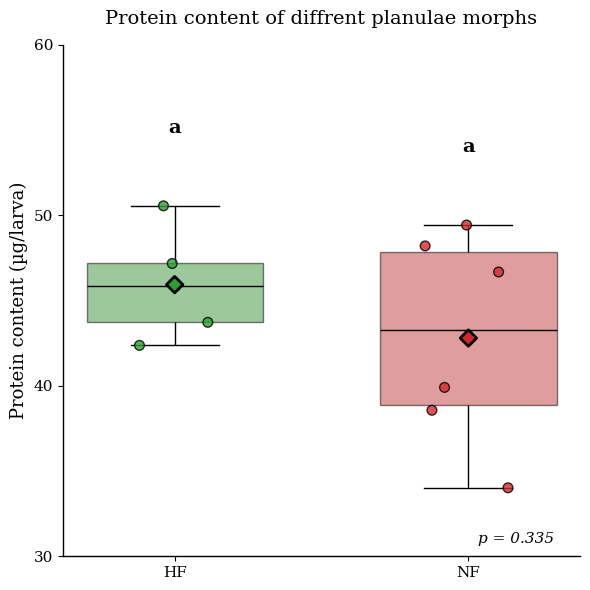

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
# Make sure your CSV file is in the same folder!
filename = 'liel12012026_562_for_code.csv'
df = pd.read_csv(filename)

# Filter out empty rows (if any)
df = df.dropna(subset=['vile no'])

# ==========================================
# 2. DATA CORRECTION (Vial 12)
# ==========================================
# Exclude Vial 12 do to sampelling errror
df = df[df['vile no'] != 12]

# Recalculate 'ug/ml per larvae' after potential modifications or for consistency
df['ug/ml per larvae'] = df['ug/ml per tube'] / df['no of planulae']

# ==========================================
# 3. STATS (T-Test)
# ==========================================
hf_vals = df[df['morph'] == 'HF']['ug/ml per larvae']
nf_vals = df[df['morph'] == 'NF']['ug/ml per larvae']

t_stat, p_val = stats.ttest_ind(hf_vals, nf_vals)
print(f"P-value: {p_val:.4f}")

# Determine letters for annotation
# If P > 0.05, both groups are statistically the same (both 'a')
if p_val < 0.05:
    letters_map = {'HF': 'a', 'NF': 'b'}
else:
    letters_map = {'HF': 'a', 'NF': 'a'}

# ==========================================
# 4. STYLING SETUP
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'axes.edgecolor': 'black', 'axes.linewidth': 1,
    'xtick.color': 'black', 'ytick.color': 'black',
    'text.color': 'black', 'axes.labelcolor': 'black',
    'legend.frameon': False,
    'ytick.labelsize': 11,
    'xtick.labelsize': 11
})

variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}  # Green and Red
morph_order = ['HF', 'NF']

plt.figure(figsize=(6, 6))

# ==========================================
# 5. PLOT CONSTRUCTION
# ==========================================

# A. Box Plot
ax = sns.boxplot(
    data=df, x='morph', y='ug/ml per larvae', order=morph_order, palette=variant_colors,
    width=0.6, showfliers=False, linewidth=1,
    boxprops=dict(edgecolor='black', alpha=0.5),
    whiskerprops=dict(color='black'), capprops=dict(color='black'), medianprops=dict(color='black')
)

# B. Jitter Points (Individual Samples)
sns.stripplot(
    data=df, x='morph', y='ug/ml per larvae', order=morph_order, hue='morph', palette=variant_colors,
    jitter=0.15, size=7, linewidth=1, edgecolor='black',
    alpha=0.8, legend=False, zorder=3
)

# C. Mean Diamond
means = df.groupby('morph')['ug/ml per larvae'].mean().reindex(morph_order)
mean_colors = [variant_colors[m] for m in morph_order]
plt.scatter(range(2), means, c=mean_colors, marker='D', s=70, edgecolors='black', linewidths=2, alpha=1.0, zorder=4)

# ==========================================
# 6. ANNOTATIONS
# ==========================================
# Letters 'a' or 'b'
y_offset_percent = 0.08
max_val_global = df['ug/ml per larvae'].max()

for i, m in enumerate(morph_order):
    subset = df[df['morph'] == m]['ug/ml per larvae']
    highest_point = subset.max()
    pos_y = highest_point + (max_val_global * y_offset_percent)

    letter = letters_map[m]
    plt.text(x=i, y=pos_y, s=letter, ha='center', va='bottom', size=14, weight='bold')

# P-value (Bottom Right)
p_text = f"p = {p_val:.3f}" if p_val >= 0.0001 else "p < 0.0001"
plt.text(0.95, 0.02, s=p_text, transform=ax.transAxes,
         ha='right', va='bottom', size=11, style='italic', color='black')

# Labels & Title
plt.ylabel("Protein content (µg/larva)", size=13)
plt.xlabel("")
plt.title("Protein content of diffrent planulae morphs", size=14, pad=15)

# Axis limits adjustment
plt.ylim(30, 60)
plt.yticks(np.arange(30, 61, 10))

sns.despine()
plt.tight_layout()

# Save options
plt.savefig("Protein_Content_by_Morph.pdf", dpi=600)
plt.savefig("Protein_Content_by_Morph.png", dpi=600)
plt.savefig("Protein_Content_by_Morph.tiff", dpi=600)
plt.savefig("Protein_Content_by_Morph_white.svg", facecolor='white')
plt.savefig("Protein_Content_by_Morph_transparent.svg", transparent=True)

plt.show()